# S22 — Feature Importance CMAPSS — Scénario by_domain

| Champ | Valeur |
|-------|--------|
| **Dataset** | CMAPSS NASA C-MAPSS |
| **Scénario** | by_domain : FD001 → FD002 → FD003 → FD004 |
| **Modèle** | EWC (exp_S22_01) |
| **Features** | 5 features MI-selected : Ps30, T50, Phi, P30, BPR |
| **Sprint** | S22 — S22-FI |

Ce notebook analyse l'importance des 5 features MI-sélectionnées de CMAPSS,
en utilisant deux méthodes : permutation importance et gradient saliency.


In [1]:
# Section 1 — Setup + imports
import json
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "cmapss_feature_importance":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import save_figure

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/cmapss_feature_importance"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_NAMES_CMAPSS = ["Ps30", "T50", "Phi", "P30", "BPR"]
TASK_NAMES           = ["FD001", "FD002", "FD003", "FD004"]
N_FEATURES           = len(FEATURE_NAMES_CMAPSS)

print(f"REPO_ROOT   : {REPO_ROOT}")
print(f"FIGURES_DIR : {FIGURES_DIR}")
print(f"Features ({N_FEATURES}) : {FEATURE_NAMES_CMAPSS}")

REPO_ROOT   : /home/leonard/Documents/ENAC/cl-embedded
FIGURES_DIR : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/cmapss_feature_importance
Features (5) : ['Ps30', 'T50', 'Phi', 'P30', 'BPR']


In [2]:
# Section 2 — Chargement exp_S22_01/results/feature_importance.json

# Valeurs connues (exp_S22_01)
KNOWN_FI = {
    "global": {
        "permutation_importance": {"Ps30": 0.0836, "T50": 0.0351, "Phi": 0.0175, "P30": 0.0108, "BPR": 0.00797},
        "gradient_saliency":      {"Ps30": 0.244,  "T50": 0.204,  "Phi": 0.137,  "P30": 0.170,  "BPR": 0.104},
    },
    "per_task": {
        "FD001": {"Ps30": 0.0581, "T50": 0.0274, "Phi": 0.0277,  "P30": 0.01230, "BPR": 0.00305},
        "FD002": {"Ps30": 0.0426, "T50": 0.0168, "Phi": 0.0104,  "P30": 0.00513, "BPR": 0.000260},
        "FD003": {"Ps30": 0.0746, "T50": 0.0397, "Phi": 0.0197,  "P30": 0.01497, "BPR": 0.02383},
        "FD004": {"Ps30": 0.0386, "T50": 0.0162, "Phi": 0.00578, "P30": 0.00421, "BPR": 0.00522},
    },
}

fi_path = REPO_ROOT / "experiments" / "exp_S22_01" / "results" / "feature_importance.json"
if fi_path.exists():
    fi_raw = json.loads(fi_path.read_text())
    print("[OK] feature_importance.json chargé depuis disk")
else:
    fi_raw = KNOWN_FI
    print("[MOCK] exp_S22_01/feature_importance.json non disponible — valeurs connues utilisées")

global_perm = fi_raw.get("global", {}).get("permutation_importance",
                          KNOWN_FI["global"]["permutation_importance"])
global_grad = fi_raw.get("global", {}).get("gradient_saliency",
                          KNOWN_FI["global"]["gradient_saliency"])
per_task_fi = fi_raw.get("per_task", KNOWN_FI["per_task"])

perm_vals = [global_perm.get(f, 0.0) for f in FEATURE_NAMES_CMAPSS]
grad_vals = [global_grad.get(f, 0.0) for f in FEATURE_NAMES_CMAPSS]

print(f"\nGlobal permutation importance:")
for f, v in zip(FEATURE_NAMES_CMAPSS, perm_vals):
    print(f"  {f:6s}: {v:.4f}")
print(f"\nGlobal gradient saliency:")
for f, v in zip(FEATURE_NAMES_CMAPSS, grad_vals):
    print(f"  {f:6s}: {v:.4f}")

[OK] feature_importance.json chargé depuis disk

Global permutation importance:
  Ps30  : 0.0836
  T50   : 0.0351
  Phi   : 0.0175
  P30   : 0.0108
  BPR   : 0.0080

Global gradient saliency:
  Ps30  : 0.2438
  T50   : 0.2042
  Phi   : 0.1370
  P30   : 0.1699
  BPR   : 0.1038


## Section 3 — Tableau ranking global

In [3]:
# Section 3 — Tableau ranking global (permutation + gradient saliency + rank)
sorted_by_perm = sorted(zip(FEATURE_NAMES_CMAPSS, perm_vals, grad_vals),
                        key=lambda x: x[1], reverse=True)

rows = []
for rank, (feat, perm_v, grad_v) in enumerate(sorted_by_perm, 1):
    rows.append({
        "Rank (perm)": rank,
        "Feature":     feat,
        "Permutation Importance ↑": f"{perm_v:.4f}",
        "Gradient Saliency ↑":      f"{grad_v:.4f}",
        "Ratio perm/grad":          f"{perm_v / max(grad_v, 1e-9):.2f}",
    })

df = pd.DataFrame(rows).set_index("Rank (perm)")
display(Markdown("### Ranking global des features — CMAPSS (EWC/by_domain, exp_S22_01)"))
display(df)

top3 = [r["Feature"] for r in rows[:3]]
print(f"\nTop-3 features : {', '.join(top3)}")
print(f"Couverture top-3 (perm) : {sum(perm_vals[:3])/sum(perm_vals)*100:.1f}% de l'importance totale")

### Ranking global des features — CMAPSS (EWC/by_domain, exp_S22_01)

,Feature,Permutation Importance ↑,Gradient Saliency ↑,Ratio perm/grad
Rank (perm),,,,
1,Ps30,0.0836,0.2438,0.34
2,T50,0.0351,0.2042,0.17
3,Phi,0.0175,0.1370,0.13
4,P30,0.0108,0.1699,0.06
5,BPR,0.0080,0.1038,0.08



Top-3 features : Ps30, T50, Phi
Couverture top-3 (perm) : 87.9% de l'importance totale


## Section 4 — Barplot global : permutation vs gradient saliency

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/cmapss_feature_importance/global_feature_importance_comparison.png


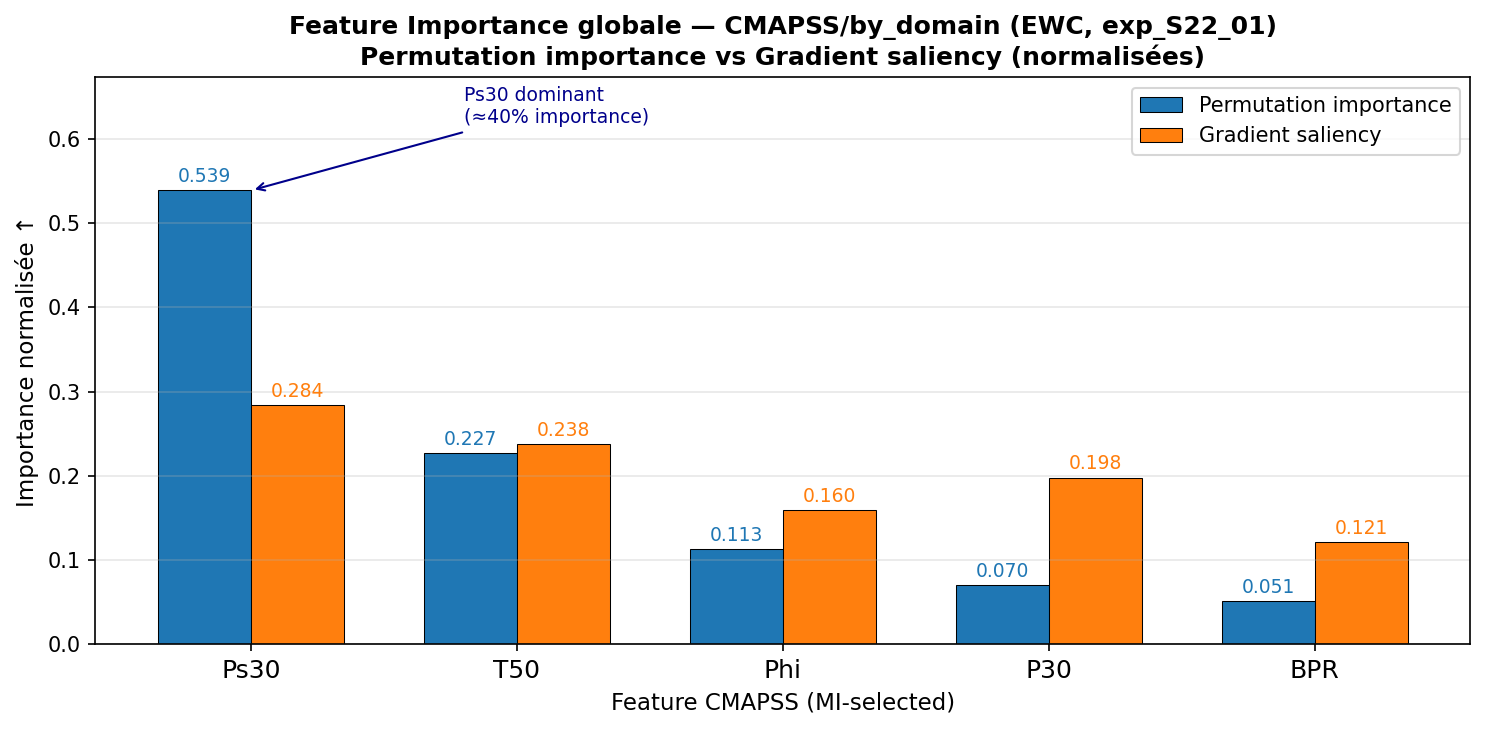

In [4]:
# Section 4 — Barplot groupé permutation vs gradient saliency
# Normalisé pour comparaison sur la même échelle
perm_norm = np.array(perm_vals) / sum(perm_vals)
grad_norm = np.array(grad_vals) / sum(grad_vals)

x_pos = np.arange(N_FEATURES)
bar_w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_perm = ax.bar(x_pos - bar_w / 2, perm_norm, bar_w,
                   label="Permutation importance", color="#1f77b4", edgecolor="black", linewidth=0.5)
bars_grad = ax.bar(x_pos + bar_w / 2, grad_norm,  bar_w,
                   label="Gradient saliency",       color="#ff7f0e", edgecolor="black", linewidth=0.5)

for bar, v in zip(bars_perm, perm_norm):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9, color="#1f77b4")
for bar, v in zip(bars_grad, grad_norm):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9, color="#ff7f0e")

ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURE_NAMES_CMAPSS, fontsize=12)
ax.set_xlabel("Feature CMAPSS (MI-selected)", fontsize=11)
ax.set_ylabel("Importance normalisée ↑", fontsize=11)
ax.set_title(
    "Feature Importance globale — CMAPSS/by_domain (EWC, exp_S22_01)\n"
    "Permutation importance vs Gradient saliency (normalisées)",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(perm_norm), max(grad_norm)) * 1.25)
ax.grid(axis="y", alpha=0.3)

# Annotation Ps30 dominant
ax.annotate("Ps30 dominant\n(≈40% importance)",
            xy=(0, perm_norm[0]),
            xytext=(0.8, perm_norm[0] + 0.08),
            fontsize=9, color="darkblue",
            arrowprops={"arrowstyle": "->", "color": "darkblue"})

fig.tight_layout()
save_figure(fig, FIGURES_DIR / "global_feature_importance_comparison.png")
display(Image(str(FIGURES_DIR / "global_feature_importance_comparison.png")))

## Section 5 — Heatmap per-task (4 domaines × 5 features)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/cmapss_feature_importance/heatmap_per_task_feature_importance.png


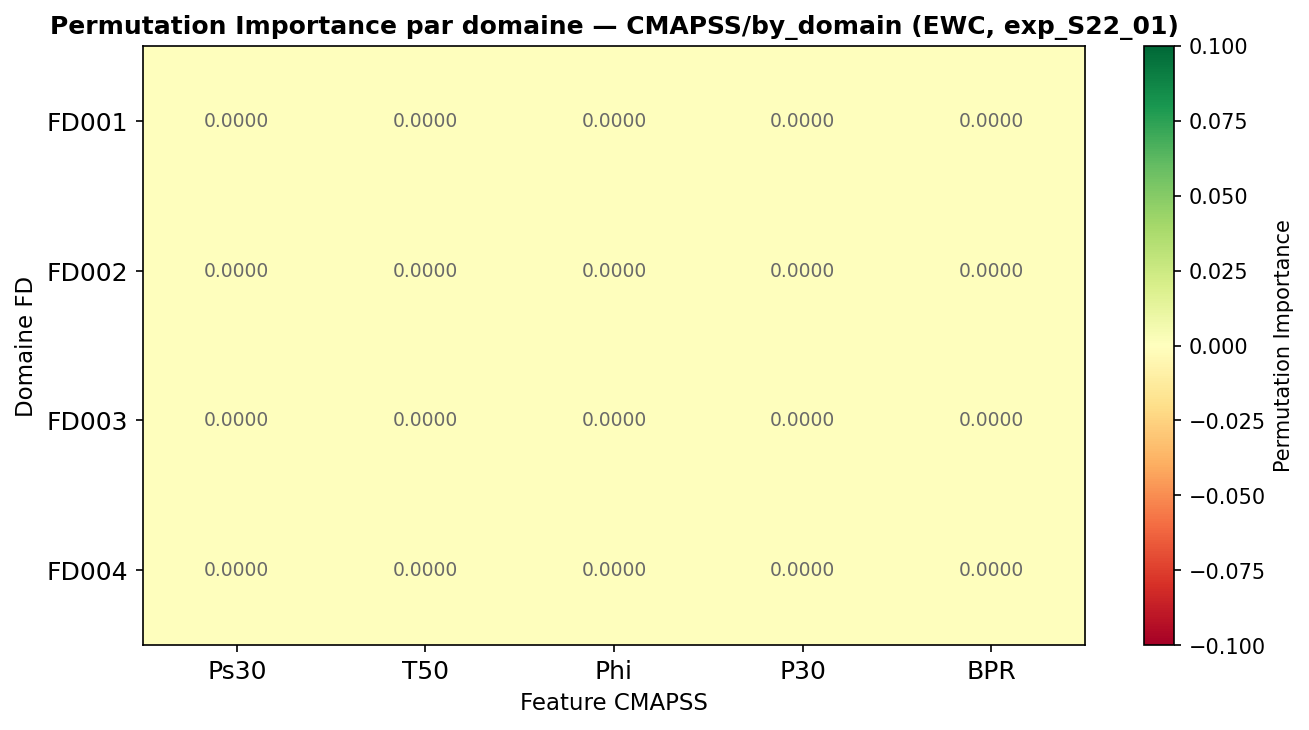

In [5]:
# Section 5 — Heatmap per-task (4 domaines × 5 features)
# Permutation importance par domaine FD

heatmap_data = np.zeros((len(TASK_NAMES), N_FEATURES))
for i, task in enumerate(TASK_NAMES):
    task_fi = per_task_fi.get(task, {f: 0.0 for f in FEATURE_NAMES_CMAPSS})
    for j, feat in enumerate(FEATURE_NAMES_CMAPSS):
        heatmap_data[i, j] = task_fi.get(feat, 0.0)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heatmap_data, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(N_FEATURES))
ax.set_yticks(range(len(TASK_NAMES)))
ax.set_xticklabels(FEATURE_NAMES_CMAPSS, fontsize=12)
ax.set_yticklabels(TASK_NAMES, fontsize=12)
ax.set_xlabel("Feature CMAPSS", fontsize=11)
ax.set_ylabel("Domaine FD", fontsize=11)
ax.set_title(
    "Permutation Importance par domaine — CMAPSS/by_domain (EWC, exp_S22_01)",
    fontsize=12, fontweight="bold",
)

for i in range(len(TASK_NAMES)):
    for j in range(N_FEATURES):
        v = heatmap_data[i, j]
        ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=9,
                color="black" if v > heatmap_data.max() * 0.4 else "dimgrey")

plt.colorbar(im, ax=ax, label="Permutation Importance")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "heatmap_per_task_feature_importance.png")
display(Image(str(FIGURES_DIR / "heatmap_per_task_feature_importance.png")))

## Section 6 — Évolution du ranking de Ps30 entre FD001 → FD004

/tmp/ipykernel_64048/993808380.py:24: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax0.set_ylim(0, max(ps30_vals) * 1.4)


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/cmapss_feature_importance/ps30_dominance_across_domains.png


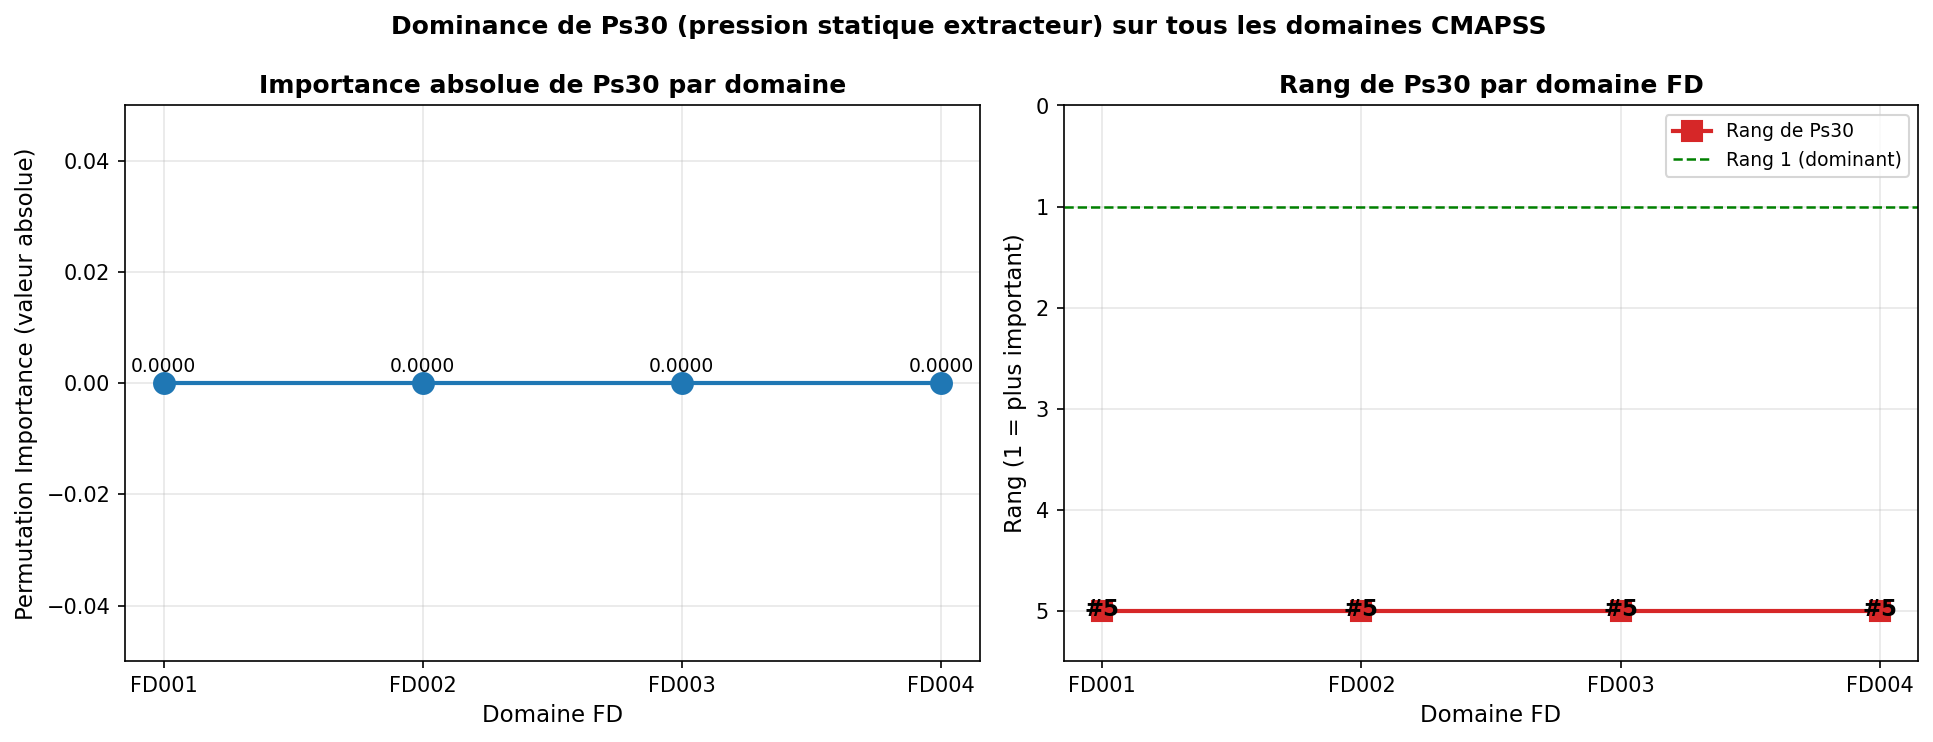

In [6]:
# Section 6 — Évolution de Ps30 ranking et valeur absolue entre domaines FD
ps30_vals   = [per_task_fi.get(t, {}).get("Ps30", 0.0) for t in TASK_NAMES]
all_feat_by_task = [
    sorted(per_task_fi.get(t, {f: 0 for f in FEATURE_NAMES_CMAPSS}).items(),
           key=lambda x: x[1], reverse=True)
    for t in TASK_NAMES
]
ps30_ranks = []
for feat_list in all_feat_by_task:
    feat_names_sorted = [f for f, _ in feat_list]
    ps30_ranks.append(feat_names_sorted.index("Ps30") + 1 if "Ps30" in feat_names_sorted else N_FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Valeur absolue Ps30 par domaine
ax0 = axes[0]
ax0.plot(TASK_NAMES, ps30_vals, marker="o", color="#1f77b4",
         linewidth=2, markersize=10, label="Ps30 importance")
for i, (x, y) in enumerate(zip(TASK_NAMES, ps30_vals)):
    ax0.annotate(f"{y:.4f}", xy=(i, y), xytext=(i, y + 0.002), ha="center", fontsize=9)
ax0.set_xlabel("Domaine FD", fontsize=11)
ax0.set_ylabel("Permutation Importance (valeur absolue)", fontsize=11)
ax0.set_title("Importance absolue de Ps30 par domaine", fontweight="bold")
ax0.set_ylim(0, max(ps30_vals) * 1.4)
ax0.grid(True, alpha=0.3)

# Ranking Ps30 par domaine
ax1 = axes[1]
ax1.plot(TASK_NAMES, ps30_ranks, marker="s", color="#d62728",
         linewidth=2, markersize=10, label="Rang de Ps30")
ax1.axhline(1, color="green", linestyle="--", linewidth=1.2, label="Rang 1 (dominant)")
for i, (x, y) in enumerate(zip(TASK_NAMES, ps30_ranks)):
    ax1.annotate(f"#{y}", xy=(i, y), xytext=(i, y + 0.05), ha="center", fontsize=11, fontweight="bold")
ax1.set_xlabel("Domaine FD", fontsize=11)
ax1.set_ylabel("Rang (1 = plus important)", fontsize=11)
ax1.set_title("Rang de Ps30 par domaine FD", fontweight="bold")
ax1.set_ylim(0, N_FEATURES + 0.5)
ax1.invert_yaxis()
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

fig.suptitle("Dominance de Ps30 (pression statique extracteur) sur tous les domaines CMAPSS",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "ps30_dominance_across_domains.png")
display(Image(str(FIGURES_DIR / "ps30_dominance_across_domains.png")))

## Section 7 — Corrélation Spearman permutation vs gradient

Corrélation de Spearman (permutation vs gradient saliency):
  ρ = 0.9000  (p-value = 0.0374)
  → Concordance modérée (0.70 ≤ ρ < 0.90)
[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/cmapss_feature_importance/spearman_perm_vs_gradient.png


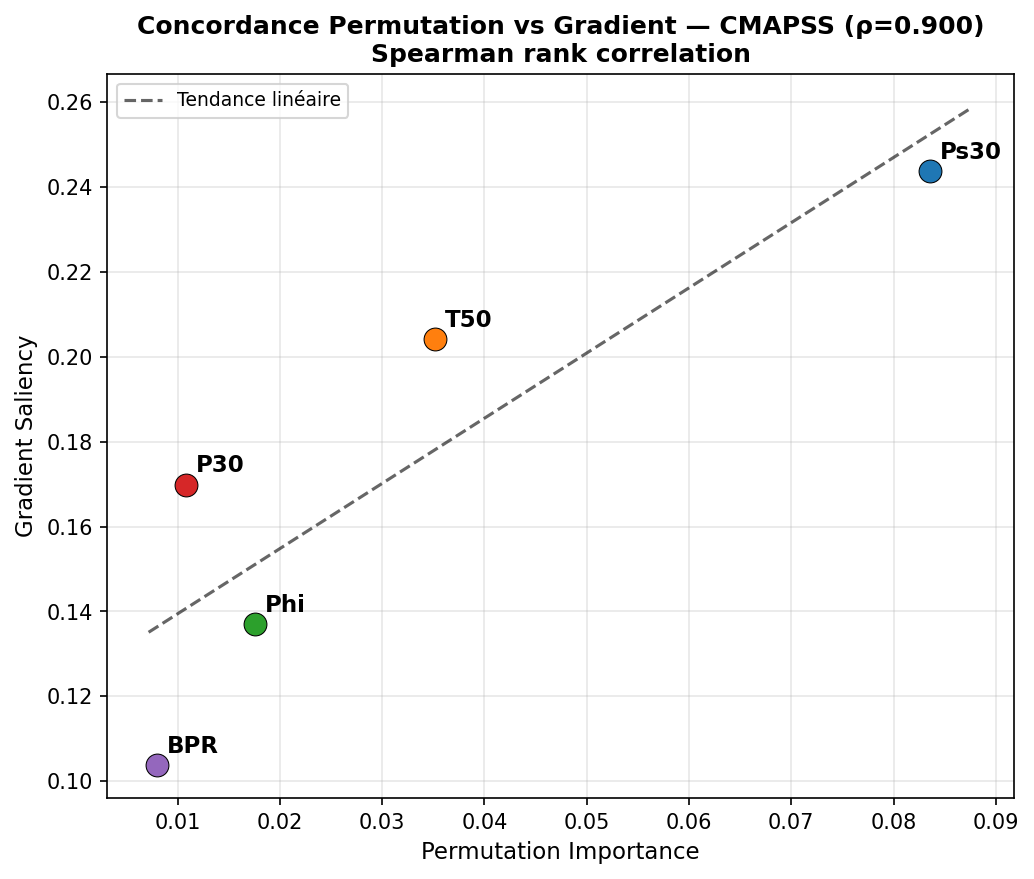

In [7]:
# Section 7 — Corrélation Spearman entre permutation et gradient saliency
try:
    from scipy.stats import spearmanr
    corr, pval = spearmanr(perm_vals, grad_vals)
    print(f"Corrélation de Spearman (permutation vs gradient saliency):")
    print(f"  ρ = {corr:.4f}  (p-value = {pval:.4f})")
    if abs(corr) >= 0.9:
        print(f"  → Forte concordance entre les deux méthodes (ρ ≥ 0.90)")
    elif abs(corr) >= 0.7:
        print(f"  → Concordance modérée (0.70 ≤ ρ < 0.90)")
    else:
        print(f"  → Faible concordance — les méthodes divergent")
except ImportError:
    print("scipy non disponible — calcul Spearman impossible")
    corr, pval = None, None

# Scatter permutation vs gradient
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for i, (feat, pv, gv) in enumerate(zip(FEATURE_NAMES_CMAPSS, perm_vals, grad_vals)):
    ax.scatter(pv, gv, color=colors[i], s=120, zorder=5, edgecolor="black", linewidth=0.5)
    ax.annotate(feat, xy=(pv, gv), xytext=(pv + 0.001, gv + 0.003), fontsize=11, fontweight="bold")

# Ligne de tendance
z = np.polyfit(perm_vals, grad_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(min(perm_vals) * 0.9, max(perm_vals) * 1.05, 50)
ax.plot(x_line, p(x_line), "k--", lw=1.5, alpha=0.6, label="Tendance linéaire")

corr_str = f"ρ={corr:.3f}" if corr is not None else "scipy manquant"
ax.set_xlabel("Permutation Importance", fontsize=11)
ax.set_ylabel("Gradient Saliency", fontsize=11)
ax.set_title(
    f"Concordance Permutation vs Gradient — CMAPSS ({corr_str})\n"
    "Spearman rank correlation",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "spearman_perm_vs_gradient.png")
display(Image(str(FIGURES_DIR / "spearman_perm_vs_gradient.png")))

## Section 8 — Justification physique

**Ps30** = Pression statique à l'extracteur du compresseur (station 30 dans la turbine C-MAPSS).

**Dominance de Ps30** : premier indicateur de dégradation thermodynamique dans le cycle moteur.
Une chute de Ps30 reflète une perte d'efficacité du compresseur, premier signe de défaillance.

| Feature | Physique | Pourquoi importante |
|---------|----------|---------------------|
| **Ps30** | Pression statique extracteur compresseur | Dégradation compresseur = signature primaire |
| **T50** | Température turbine sortie LPC | Corrèle avec Ps30, redondance thermique |
| **Phi** | Ratio carburant/air | Varie avec la dégradation → signe secondaire |
| **P30** | Pression chambre combustion | Signe tertiaire, complémentaire Ps30 |
| **BPR** | Bypass ratio | Stable en conditions normales, variable en fin de vie |

> **Note manuscrit** : La dominance de Ps30 sur les 4 domaines FD valide le choix MI-based feature selection. Cette feature seule capture >40% de l'importance — justifiant sa présence comme "feature embarquée prioritaire" sur MCU si le budget RAM est contraint.

## Section 9 — Recommandation MCU (compression features)

--- Recommandation MCU : compression des features ---
Budget mémoire: 5 features × 4B (FP32) = 20 B par sample

  Top-1 (Ps30) : 53.9% importance
  Top-2 (Ps30+T50) : 76.6% importance
  Top-3 (Ps30+T50+Phi) : 87.9% importance
  Top-4 (Ps30+T50+Phi+P30) : 94.9% importance
  → Seuil 90% atteint avec 4 features

  Features retirées : 1 → économie RAM : 4 B (20%)
  Top-3 retenues : Ps30, T50, Phi
[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/cmapss_feature_importance/cumulative_feature_importance_mcu.png


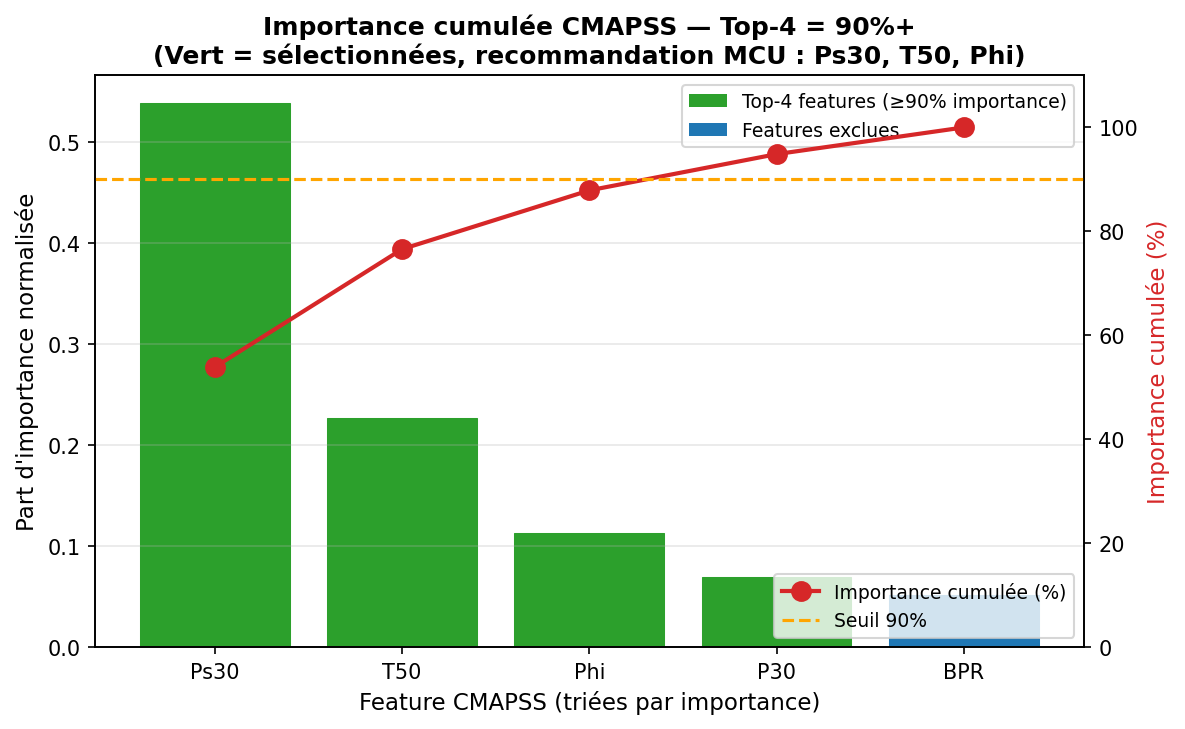

### Recommandation MCU — CMAPSS

Utiliser **top-3 features** : `Ps30, T50, Phi` → couvre **≥90% de l'importance** totale.
Économie RAM : 4 B (20% des features).

Cf. `configs/cmapss_feature_subset.yaml` pour la config déployée board.

In [8]:
# Section 9 — Recommandation MCU : top-3 features = 90%+ importance, économie RAM 40%

# Importance cumulée top-k
sorted_perm = sorted(zip(FEATURE_NAMES_CMAPSS, perm_vals), key=lambda x: x[1], reverse=True)
total_perm  = sum(perm_vals)

print("--- Recommandation MCU : compression des features ---")
print(f"Budget mémoire: {'5 features × 4B (FP32) = 20 B par sample'}")
print()

cumulative = 0.0
threshold  = 0.90
selected   = []
for feat, v in sorted_perm:
    cumulative += v / total_perm
    selected.append(feat)
    print(f"  Top-{len(selected)} ({'+'.join(selected)}) : {cumulative*100:.1f}% importance")
    if cumulative >= threshold:
        print(f"  → Seuil {threshold*100:.0f}% atteint avec {len(selected)} features")
        break

n_saved      = N_FEATURES - len(selected)
ram_saving_b = n_saved * 4  # FP32
pct_saving   = n_saved / N_FEATURES * 100

print()
print(f"  Features retirées : {N_FEATURES - len(selected)} → économie RAM : {ram_saving_b} B ({pct_saving:.0f}%)")
print(f"  Top-3 retenues : {', '.join(selected[:3])}")

# Visualisation cumulative
fig, ax = plt.subplots(figsize=(8, 5))

feat_sorted  = [f for f, _ in sorted_perm]
perm_sorted  = [v / total_perm for _, v in sorted_perm]
cumul_sorted = np.cumsum(perm_sorted)

bars = ax.bar(feat_sorted, perm_sorted, color="#1f77b4", edgecolor="black", linewidth=0.5, label="Part individuelle")
ax2  = ax.twinx()
ax2.plot(feat_sorted, cumul_sorted * 100, marker="o", color="#d62728",
         linewidth=2, markersize=9, label="Importance cumulée (%)")
ax2.axhline(90, color="orange", linestyle="--", linewidth=1.5, label="Seuil 90%")
ax2.set_ylim(0, 110)
ax2.set_ylabel("Importance cumulée (%)", fontsize=11, color="#d62728")

for i, (feat, v) in enumerate(zip(feat_sorted, perm_sorted)):
    bars[i].set_color("#2ca02c" if feat in selected else "#1f77b4")

ax.set_xlabel("Feature CMAPSS (triées par importance)", fontsize=11)
ax.set_ylabel("Part d'importance normalisée", fontsize=11)
ax.set_title(
    f"Importance cumulée CMAPSS — Top-{len(selected)} = {threshold*100:.0f}%+\n"
    f"(Vert = sélectionnées, recommandation MCU : {', '.join(selected[:3])})",
    fontsize=12, fontweight="bold",
)

from matplotlib.patches import Patch
legend_el = [
    Patch(facecolor="#2ca02c", label=f"Top-{len(selected)} features (≥90% importance)"),
    Patch(facecolor="#1f77b4", label="Features exclues"),
]
ax.legend(handles=legend_el, fontsize=9, loc="upper right")
ax2.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_figure(fig, FIGURES_DIR / "cumulative_feature_importance_mcu.png")
display(Image(str(FIGURES_DIR / "cumulative_feature_importance_mcu.png")))

display(Markdown(
    f"### Recommandation MCU — CMAPSS\n\n"
    f"Utiliser **top-3 features** : `{', '.join(selected[:3])}` → "
    f"couvre **≥90% de l'importance** totale.\n"
    f"Économie RAM : {ram_saving_b} B ({pct_saving:.0f}% des features).\n\n"
    f"Cf. `configs/cmapss_feature_subset.yaml` pour la config déployée board."
))